# Data Analysis Mathematics, Algorithms and Modeling

## Team Information - **Group Presentation 4**

**Team Members**

Name: Ayush Patel  
Student Number: 9033358

Name: Nikhil Shankar  
Student Number: 9026254

Name: Sreehari Prathap  
Student Number: 8903199


### **Prerequisites**
- Install Anaconda (for Jupyter Notebook) and Visual Studio Code (VS Code).
  - Anaconda: Visit [anaconda.com](https://www.anaconda.com/products/individual) and download the appropriate installer for your operating system.
  - VS Code: Download and install from [Visual Studio Code](https://code.visualstudio.com/).
- Install Pandas Library
  - Open the terminal and run the following command: `pip install pandas`

### **STEP : 1** - Collection and Preparation of Data
We are using the Salary data dataset from [Kaggle], which can be downloaded directly via the link:
- URL: [https://www.kaggle.com/datasets/mohithsairamreddy/salary-data]

A The dataset was obtained from multiple sources, including surveys, job posting sites, and other publicly available sources. A total of 6704 data points were collected.

The dataset included five variables: age, experience, job role, and education level and salary

### **STEP : 2** - Code Encapsulation into Classes and Methods

In [68]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Class to handle employee data loading and preprocessing
class IterationHelper:
    def __init__(self, file_path, feature_list):
        self.file_path = file_path
        self.data = None
        self.feature_list = feature_list

    def performIteration(self):
        employee_data = EmployeeData(self.file_path,
                             self.feature_list)
        data = employee_data.load_data()
        features = employee_data.preprocess_data()
        employee_data.gender_summary_statistics()
        # Step 2: Perform clustering
        clustering = EmployeeClustering(features)
        clustering.scale_features()
        clustering.find_optimal_k()
        clustered_data = clustering.apply_kmeans()
        # Step 3: Visualize the clusters
        for i,x in enumerate(employee_data.feature_list):
            for j in range(i+1, len(employee_data.feature_list)):
                if(x != employee_data.feature_list[j]):
                    clustering.visualize_clusters(x, employee_data.feature_list[j])
    
class EmployeeData:
    def __init__(self, file_path, feature_list):
        self.file_path = file_path
        self.data = None
        self.feature_list = feature_list


    def load_data(self):
        self.data = pd.read_csv(self.file_path)
        return self.data

    def preprocess_data(self):
        # Convert categorical data to numerical (if needed)
        self.data['Gender'] = self.data['Gender'].map({'Male': 0, 'Female': 1})
        # Select features for clustering
        self.features = self.data[self.feature_list]
        return self.features

    def gender_summary_statistics(self):
        # Display summary statistics by gender for key metrics
        summary_stats = self.data.groupby('Gender').agg({
            'Monthly_Salary': ['mean', 'median'],
            'Years_At_Company': ['mean', 'median'],
            'Performance_Score': ['mean', 'median'],
            'Promotions': ['mean', 'median'],
            'Employee_Satisfaction_Score': ['mean', 'median']
        })
        print("Summary Statistics by Gender:\n", summary_stats)
        
        # # Visualizations to check distributions by gender
        # plt.figure(figsize=(10, 6))
        # sns.boxplot(x='Gender', y='Monthly_Salary', data=self.data)
        # plt.title("Monthly Salary Distribution by Gender")
        # plt.show()

        # plt.figure(figsize=(10, 6))
        # sns.boxplot(x='Gender', y='Performance_Score', data=self.data)
        # plt.title("Performance Score Distribution by Gender")
        # plt.show()

class Plotters:
    def plot_scatter(df, x, y, title, x_label, y_label):
        # Plot a scatter plot to visualize the relationship between two variables
        plt.figure(figsize=(10, 6))
        plt.scatter(df[x], df[y])
        plt.title(title)
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        # Calculate and display summary statistics
        x_mean = df[x].mean()
        y_mean = df[y].mean()
        correlation = df[[x, y]].corr().iloc[0, 1]
        summary_text = (
            f"Summary:\n"
            f"Mean of {x}: {x_mean:.2f}\n"
            f"Mean of {y}: {y_mean:.2f}\n"
            f"Correlation between {x} and {y}: {correlation:.2f}"
        )
        plt.figtext(0.15, -0.1, summary_text, wrap=True, fontsize=12, ha='left')
        plt.show()
        
    def plot_scatter_diagram(df, dependent_column_name):
        fig, axes = plt.subplots(4, int((len(df.columns)/4) + 1),figsize=(15,15))
        for i, col_name in enumerate(df.columns):
            if col_name != dependent_column_name:
                sns.scatterplot(x=col_name, y=dependent_column_name, data=df, ax=axes[i%4, i//4])
        plt.tight_layout()
        plt.show()

# Class to handle clustering operations
class EmployeeClustering:
    def __init__(self, data):
        self.data = data
        self.scaled_data = None
        self.model = None
        self.optimal_k = None

    def scale_features(self):
        scaler = StandardScaler()
        self.scaled_data = scaler.fit_transform(self.data)
        return self.scaled_data

    def find_optimal_k(self, max_k=10):
        sse = []
        for k in range(1, max_k + 1):
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(self.scaled_data)
            sse.append(kmeans.inertia_)
        
        plt.plot(range(1, max_k + 1), sse)
        plt.xlabel("Number of Clusters (K)")
        plt.ylabel("SSE")
        plt.title("Elbow Method to Find Optimal K")
        plt.show()
        
        # After identifying optimal K from the plot, assign it
        self.optimal_k = int(input("Enter the optimal number of clusters (K) from the Elbow plot: "))

    def apply_kmeans(self):
        self.model = KMeans(n_clusters=self.optimal_k, random_state=42)
        self.data['Cluster'] = self.model.fit_predict(self.scaled_data)
        return self.data

    def visualize_clusters(self, x, y):
        plt.figure(figsize=(4, 4))
        sns.scatterplot(
            x=self.data[x], 
            y=self.data[y], 
            hue=self.data['Cluster'], 
            palette='viridis'
        )
        plt.title(f"Employee Clusters in {x} and {y}")
        plt.show()

# Class to handle bias analysis
class BiasAnalysis:
    def __init__(self, data):
        self.data = data

    def perform_statistical_tests(self):
        # Test for bias in Monthly Salary by Gender
        male_salary = self.data[self.data['Gender'] == 0]['Monthly_Salary']
        female_salary = self.data[self.data['Gender'] == 1]['Monthly_Salary']
        t_stat, p_val = ttest_ind(male_salary, female_salary)
        print("Monthly Salary T-test between Genders: T-statistic =", t_stat, ", P-value =", p_val)

        # Test for bias in Performance Score by Gender
        male_performance = self.data[self.data['Gender'] == 0]['Performance_Score']
        female_performance = self.data[self.data['Gender'] == 1]['Performance_Score']
        t_stat, p_val = ttest_ind(male_performance, female_performance)
        print("Performance Score T-test between Genders: T-statistic =", t_stat, ", P-value =", p_val)




#### EDA

In [69]:
# Load and clean data
employee_data = EmployeeData('../data/Extended_Employee_Performance_and_Productivity_Data.csv',
                             ['Age', 'Monthly_Salary'])
data = employee_data.load_data()
features = employee_data.preprocess_data()
employee_data.gender_summary_statistics()
display(employee_data.data)
display(len(employee_data.data))

Summary Statistics by Gender:
        Monthly_Salary         Years_At_Company        Performance_Score  \
                 mean  median             mean median              mean   
Gender                                                                    
0.0       6400.481980  6500.0         4.468239    4.0          2.999854   
1.0       6404.986354  6500.0         4.486261    4.0          2.990417   

              Promotions        Employee_Satisfaction_Score         
       median       mean median                        mean median  
Gender                                                              
0.0       3.0   1.000645    1.0                    2.994508   2.99  
1.0       3.0   0.998438    1.0                    3.004598   3.00  


,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,0.0,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,0.0,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,0.0,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,1.0,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,1.0,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,Finance,0.0,27,Technician,2022-12-07 08:03:05.556036,1,Bachelor,4,4900.0,55,46,5,3,75,16,48,2,1.28,False
99996,99997,IT,1.0,36,Consultant,2018-07-24 08:03:05.556036,6,Master,5,8250.0,39,35,7,0,0,10,77,1,3.48,True
99997,99998,Operations,0.0,53,Analyst,2015-11-24 08:03:05.556036,8,High School,2,4800.0,31,13,6,5,0,5,87,1,2.60,False
99998,99999,HR,1.0,22,Consultant,2015-08-03 08:03:05.556036,9,High School,5,8250.0,35,43,10,1,75,2,31,1,3.10,False


100000

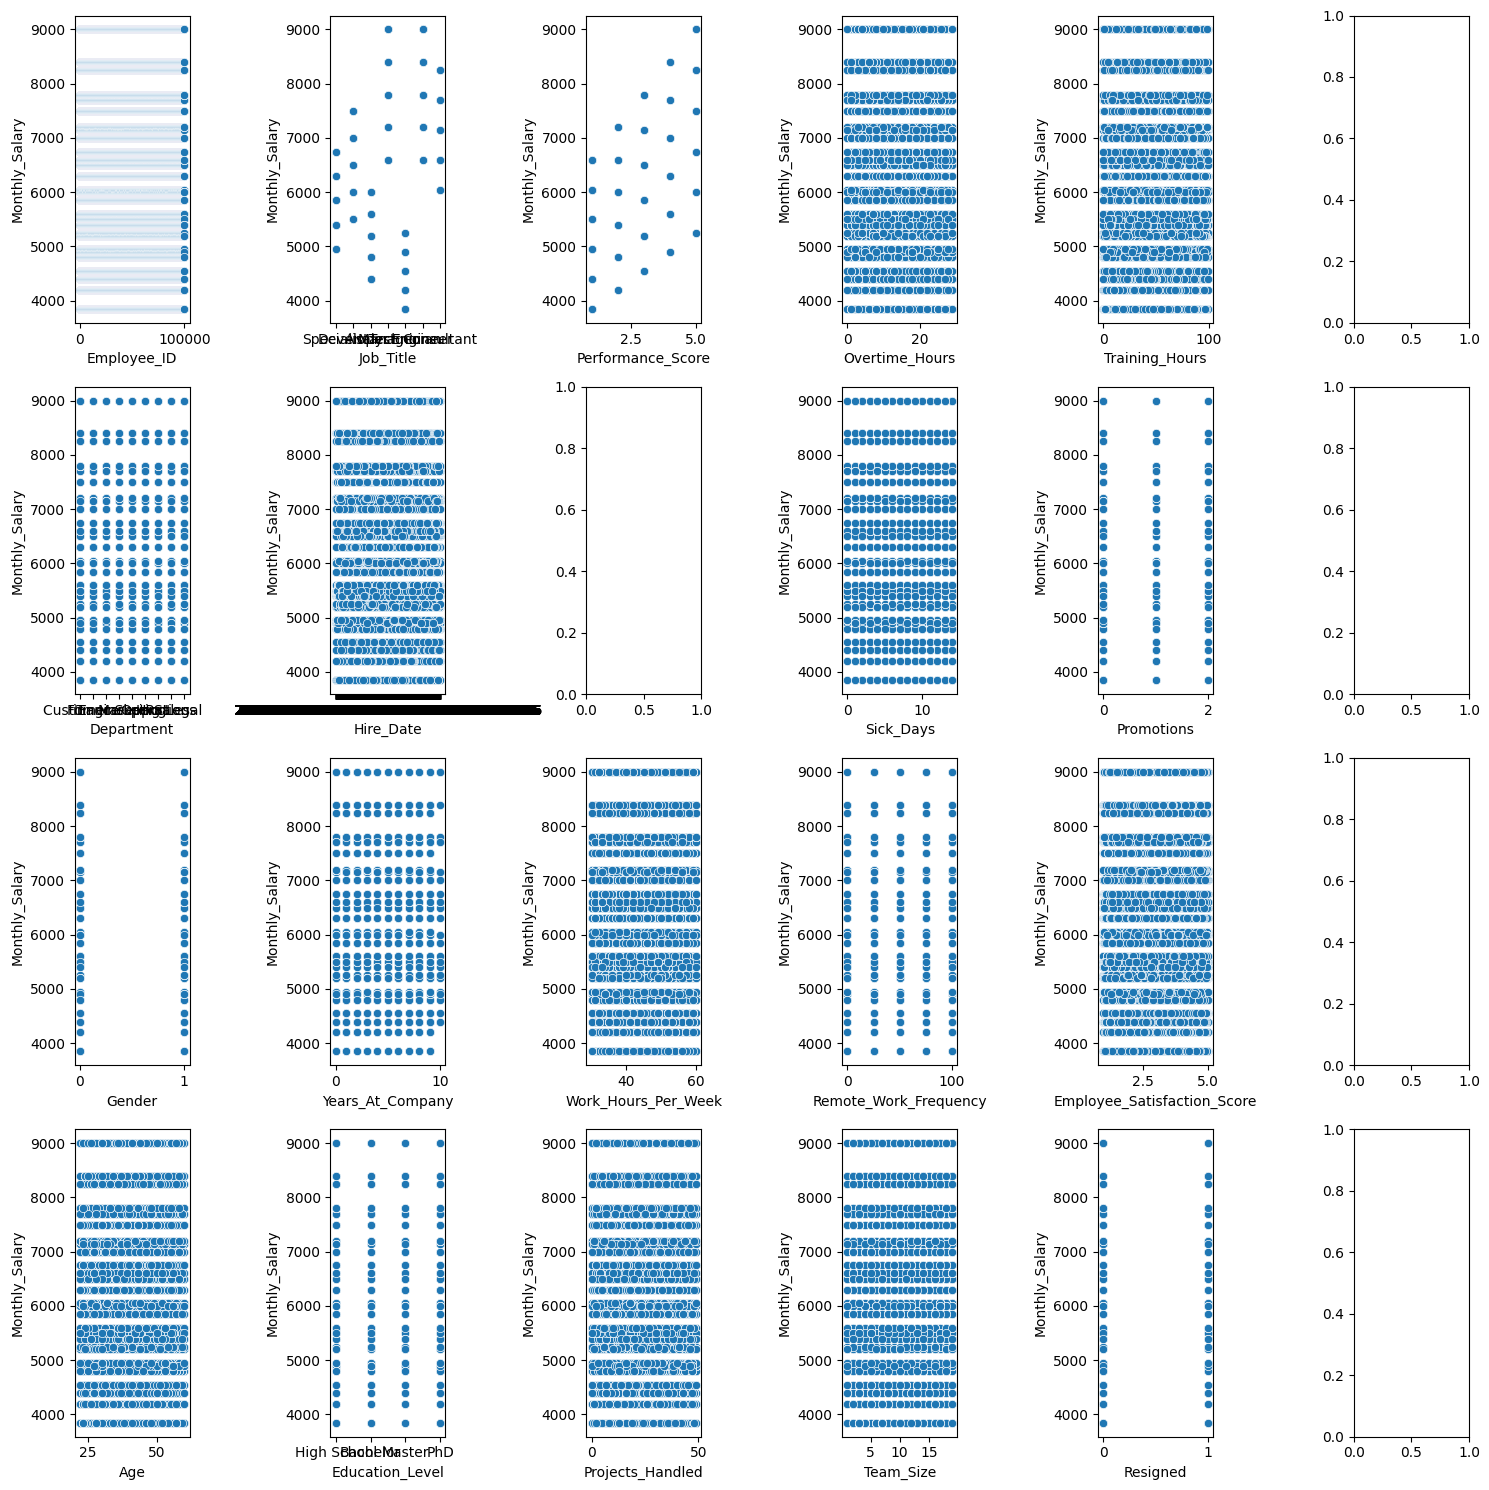

In [70]:
Plotters.plot_scatter_diagram(employee_data.data, 'Monthly_Salary')

### **STEP : 3** - Summary of use case

> #### This analysis compares fresher hiring trends across the top three job departments, examining data year by year from 1988 to 2022. The objective is to identify variations in hiring patterns over time across these departments and explore any noticeable shifts in recruitment strategies. Additionally, we aim to assess if gender-based biases are present within the hiring processes of these fields. Our revised hypothesis suggests that hiring trends vary significantly over the years for different departments, and gender bias, if present, could influence these patterns. Hypothesis testing will validate if such trends and biases are statistically significant.

### **STEP : 4** - Clustering Summary
"Clustering allows us to group employees with similar attributes (e.g., job title, performance score) to identify patterns and trends within the company. This can help in resource allocation, understanding job satisfaction trends, or predicting resignations."

### **STEP : 5** - Apply K-Means Clustering

> #### Select Features for Clustering: Choose relevant columns like Age, Years_At_Company, Monthly_Salary, Work_Hours_Per_Week, Employee_Satisfaction_Score.

c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\DELL\Desktop\Conestoga\AIML\Fou

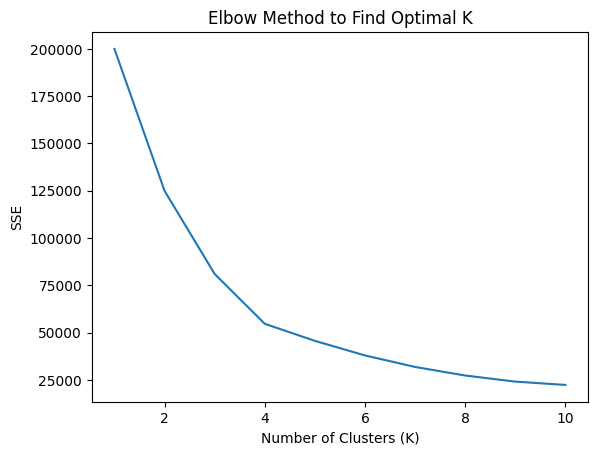

c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_13864\2338178079.py:133: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Cluster'] = self.model.fit_predict(self.scaled_data)


In [71]:
# Step 2: Perform clustering
clustering = EmployeeClustering(features)
clustering.scale_features()
clustering.find_optimal_k()
clustered_data = clustering.apply_kmeans()



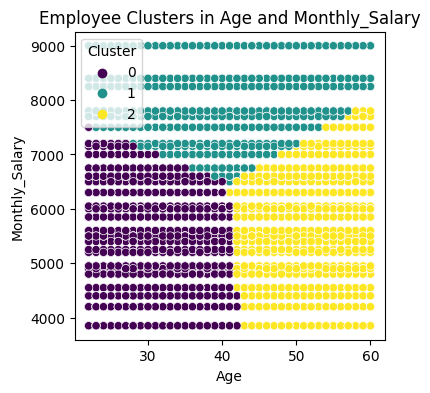

In [72]:
# Step 3: Visualize the clusters
for i,x in enumerate(employee_data.feature_list):
    for j in range(i+1, len(employee_data.feature_list)):
        if(x != employee_data.feature_list[j]):
            clustering.visualize_clusters(x, employee_data.feature_list[j])



Iteration 2

Summary Statistics by Gender:
        Monthly_Salary         Years_At_Company        Performance_Score  \
                 mean  median             mean median              mean   
Gender                                                                    
0.0       6400.481980  6500.0         4.468239    4.0          2.999854   
1.0       6404.986354  6500.0         4.486261    4.0          2.990417   

              Promotions        Employee_Satisfaction_Score         
       median       mean median                        mean median  
Gender                                                              
0.0       3.0   1.000645    1.0                    2.994508   2.99  
1.0       3.0   0.998438    1.0                    3.004598   3.00  


c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\DELL\Desktop\Conestoga\AIML\Fou

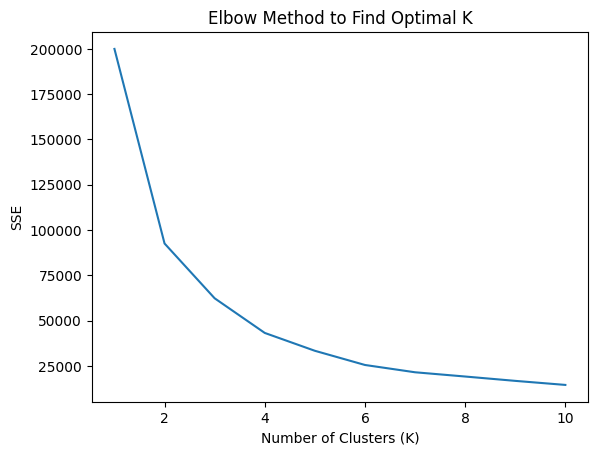

c:\Users\DELL\Desktop\Conestoga\AIML\FoundationsMachineLearningFramework\Lab\venvs\CSCN8010_classical_ml_311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_13864\2338178079.py:133: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Cluster'] = self.model.fit_predict(self.scaled_data)


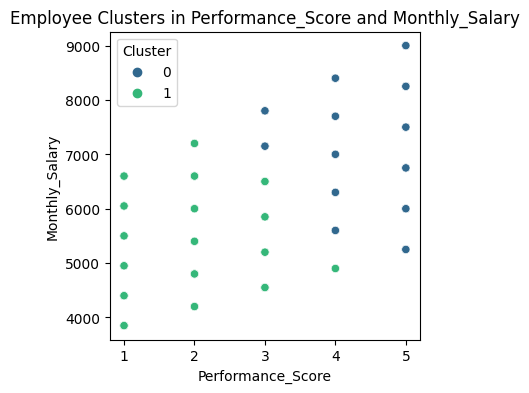

In [74]:
iteartion2 = IterationHelper('../data/Extended_Employee_Performance_and_Productivity_Data.csv',
                             ['Performance_Score', 'Monthly_Salary'])
iteartion2.performIteration()